# Physical Metrics Tutorial — SkillCorner edition

This notebook builds physical metrics from SkillCorner tracking: speed bands,
sustained efforts, TIP/OTIP rates, PSV-99, and a transparent explosiveness proxy.

$$\text{rate}_{P60\ BIP}=\frac{\text{TIP + OTIP volume}\times 60}{
\text{TIP + OTIP minutes}}$$

The code cells use the reusable `physical` package; the Markdown records only the
definitions needed to reproduce the analysis.

**Data.** The public [SkillCorner Open Data](https://github.com/SkillCorner/opendata)
sample: 10 A-League 2024/25 matches with extrapolated tracking at 10 Hz. Unlike the
other tutorials in this repo, this one needs the **tracking** files, which are stored
with Git LFS (~90 MB per match). `physical.skillcorner_tracking` fetches them from the
media endpoint; the plain `raw.githubusercontent.com` URL returns a 133-byte pointer.

Ten matches are a reproducible worked example, not a league table or scouting output.

## 0. Setup — libraries, toggles, and helpers

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_SOURCE = "opendata"   # "opendata" (public 10-match sample) or "local" (your SkillCorner bundle)
SEASON = "2024/25"
LOCAL_SKILLCORNER_ROOT = os.environ.get("SKILLCORNER_ROOT")

root = Path.cwd().resolve()
for p in [root, *root.parents]:
    if (p / "physical").exists() and (p / "xthreat").exists():
        root = p
        break
for p in [root, root / "football-cdf"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from physical import PhysicalConfig, POSITION_GROUPS, compute_player_match_metrics
from physical.kinematics import add_kinematics, canonicalize, prepare_kinematics
from physical.physical_features import activity_peak_speeds, find_efforts, psv
from physical.skillcorner_tracking import (
    OPENDATA_MATCH_IDS,
    download_skillcorner_opendata,
    iter_skillcorner_tracking,
    load_dynamic_events,
    load_skillcorner_bundle,
    resolve_match_files,
)
import physical.physical_plots as P

OPENDATA_CACHE = root / "tmp/data/skillcorner_opendata"
FIGURES = root / "tmp/figs/physical"
DATA_ROOT = Path(LOCAL_SKILLCORNER_ROOT) if DATA_SOURCE == "local" and LOCAL_SKILLCORNER_ROOT else OPENDATA_CACHE

config = PhysicalConfig()
print("definition version:", config.estimator, "| sample rate:", config.sample_hz, "Hz | dt:", config.dt, "s")
print("speed bands (km/h): running >=", config.thresholds.running_min_kmh,
      "| HSR >=", config.thresholds.hsr_min_kmh, "| sprint >", config.thresholds.sprint_min_kmh)
print("effort must be sustained >=", config.speed_activity_min_seconds, "s")

definition version: trailing_mean | sample rate: 10.0 Hz | dt: 0.1 s
speed bands (km/h): running >= 15.0 | HSR >= 20.0 | sprint > 25.0
effort must be sustained >= 0.7 s


`"opendata"` downloads the public sample; `"local"` reads
`$SKILLCORNER_ROOT`. Both paths produce the same canonical frame.

## 1. Build a canonical tracking table

### 1-1. Inspect one raw tracking frame

Tracking is JSON-lines at 10 Hz. Inspect one frame before computing kinematics.

In [2]:
import json

DEMO_MATCH = 1886347

if DATA_SOURCE == "opendata":
    download_skillcorner_opendata(OPENDATA_CACHE, match_ids=[DEMO_MATCH])

files = resolve_match_files(DEMO_MATCH, DATA_ROOT)
{k: (v.name if v else None) for k, v in files.items()}

{'match': '1886347_match.json',
 'tracking': '1886347_tracking_extrapolated.jsonl',
 'dynamic_events': '1886347_dynamic_events.csv',
 'phases_of_play': '1886347_phases_of_play.csv'}

In [3]:
with open(files["tracking"]) as handle:
    for line in handle:
        frame = json.loads(line)
        if frame.get("period") is not None and frame.get("player_data"):
            break

print("top-level keys:", list(frame))
print("period", frame["period"], "| frame", frame["frame"], "| timestamp", frame["timestamp"])
print("ball_data:", frame["ball_data"])
print("possession:", frame["possession"])
print("tracked players:", len(frame["player_data"]))
frame["player_data"][:3]

top-level keys: ['frame', 'timestamp', 'period', 'ball_data', 'possession', 'image_corners_projection', 'player_data']
period 1 | frame 10 | timestamp 00:00:00.00
ball_data: {'x': 0.32, 'y': 0.38, 'z': 0.13, 'is_detected': True}
possession: {'player_id': None, 'group': None}
tracked players: 22


[{'x': -39.63, 'y': -0.08, 'player_id': 51009, 'is_detected': False},
 {'x': -19.21, 'y': -9.18, 'player_id': 176224, 'is_detected': True},
 {'x': -21.83, 'y': 0.47, 'player_id': 51649, 'is_detected': True}]

The coordinates are positions in metres; speed and acceleration are reconstructed.
`player_data[].is_detected` marks measured versus extrapolated player positions.
For the public Physical workflow, BIP is TIP + OTIP: a frame is included when the
possession label identifies either team. This matches the published aggregate
denominator `minutes_full_tip + minutes_full_otip`; unowned frames are reported for
quality diagnostics but are not used in canonical P60 rates.

### 1-2. Metadata, lineup, and the canonical frame

`load_skillcorner_bundle` turns `match.json` into match metadata plus a lineup table
carrying each player's team, role, appearance window, and provider playing time.

In [4]:
bundle = load_skillcorner_bundle(files["match"], season=SEASON)
meta = bundle.match_metadata
print(f"{meta['home_team_name']} vs {meta['away_team_name']}  ({meta['competition_name']} {meta['season']})")
print(f"pitch {meta['pitch_length']} x {meta['pitch_width']} m | {meta['source_fps']} fps | ball state = {meta['ball_state_definition']}")

bundle.lineup[["player_name", "home_away", "position", "position_group",
               "appearance_start_seconds", "appearance_end_seconds",
               "provider_playing_time_ms"]].head(6)

Auckland FC vs Newcastle  (A-League 2024/25)
pitch 104.0 x 68.0 m | 10.0 fps | ball state = possession.team_id-tip_plus_otip-v1


,player_name,home_away,position,position_group,appearance_start_seconds,appearance_end_seconds,provider_playing_time_ms
0,N. Pijnaker,home,LCB,Central Defender,0.0,5904.9,5904000.0
1,L. Verstraete,home,CDM,Midfield,0.0,5904.9,5904000.0
2,G. May,home,CF,Forward,0.0,5199.9,5199000.0
3,A. Paulsen,home,GK,Goalkeeper,0.0,5904.9,5904000.0
4,L. Gillion,home,LWF,Winger,0.0,5904.9,5904000.0
5,F. De Vries,home,LB,Full Back,0.0,5904.9,5904000.0


In [5]:
print("position groups on this feed:", sorted(POSITION_GROUPS))
print()
print(bundle.lineup["position_group"].value_counts(dropna=False).to_string())
print()
print("unused substitutes resolve to <NA>:",
      int(bundle.lineup["position_group"].isna().sum()),
      "and all of them have no playing time:",
      int(bundle.lineup.loc[bundle.lineup["position_group"].isna(), "provider_playing_time_ms"].isna().sum()))

position groups on this feed: ['Central Defender', 'Forward', 'Full Back', 'Goalkeeper', 'Midfield', 'Winger']

position_group
Midfield            8
<NA>                7
Central Defender    5
Forward             5
Winger              5
Full Back           4
Goalkeeper          2

unused substitutes resolve to <NA>: 7 and all of them have no playing time: 7


In [7]:
tracking = pd.concat(
    iter_skillcorner_tracking(files["tracking"], bundle, chunk_frames=20_000),
    ignore_index=True,
)
print(f"{len(tracking):,} rows  ({tracking['ball'].sum():,.0f} ball + {(~tracking['ball']).sum():,.0f} player)")
tracking.head(3)

1,015,118 rows  (59,042 ball + 956,076 player)


,provider,season,match_id,period_id,period,frame_id,source_frame_id,timestamp,match_seconds,source_timestamp,...,player_id,team_id,home_away,ball,x,y,z,is_detected,ball_state,ball_owning_team_id
0,skillcorner,2024/25,1886347,1,first_half,10,10,0.0,0.0,2024-11-30 04:00:00.000,...,<NA>,<NA>,<NA>,True,0.323077,0.38,0.13,True,dead,<NA>
1,skillcorner,2024/25,1886347,1,first_half,10,10,0.0,0.0,2024-11-30 04:00:00.000,...,51009,1805,away,False,-40.011058,-0.08,NaN,False,dead,<NA>
2,skillcorner,2024/25,1886347,1,first_half,10,10,0.0,0.0,2024-11-30 04:00:00.000,...,50983,1805,away,False,-1.171154,-32.47,NaN,True,dead,<NA>


### 1-3. How completely is this match tracked?

In [8]:
ball = tracking[tracking["ball"].fillna(False)]
players = tracking[~tracking["ball"].fillna(False)]

live_frames = int((ball["ball_state"] == "alive").sum())
live_rows = int((players["ball_state"] == "alive").sum())

print(f"ball-in-play, frame-weighted : {100 * live_frames / len(ball):5.2f}%   ({live_frames:,}/{len(ball):,} frames)")
print(f"ball-in-play, player-weighted: {100 * live_rows / len(players):5.2f}%   ({live_rows:,}/{len(players):,} rows)")
print()
print(f"tracked players per LIVE frame: {live_rows / live_frames:5.2f}")
print(f"tracked players per DEAD frame: {(len(players) - live_rows) / (len(ball) - live_frames):5.2f}")
print(f"detected (not extrapolated)   : {100 * players['is_detected'].fillna(False).mean():5.1f}%")

ball-in-play, frame-weighted : 54.37%   (32,100/59,042 frames)
ball-in-play, player-weighted: 72.53%   (693,484/956,076 rows)

tracked players per LIVE frame: 21.60
tracked players per DEAD frame:  9.75
detected (not extrapolated)   :  59.3%


## 2. From positions to speed

In [9]:
kin = prepare_kinematics(tracking, bundle.lineup, config)
print(f"{len(kin):,} player-frames | new columns: {[c for c in kin.columns if c in ('segment_id','dt','speed_mps','acceleration_mps2','step_distance_m','raw_step_distance_m','valid_interval','is_bip')]}")

demo_player = (
    kin.groupby("player_id")["step_distance_m"].sum().idxmax()
)
name = bundle.lineup.set_index("player_id").loc[demo_player, "player_name"]
print("busiest player:", name)

955,349 player-frames | new columns: ['segment_id', 'dt', 'speed_mps', 'acceleration_mps2', 'step_distance_m', 'raw_step_distance_m', 'valid_interval', 'is_bip']
busiest player: F. Gallegos


Segments split at period changes or gaps over 0.5 s; no derivative crosses a split.
Speeds above 40 km/h and accelerations above 8 m/s² are invalid, not clipped.
Distance uses `speed × dt`; raw path length is retained as a diagnostic.

In [10]:
observed = kin[kin["valid_interval"] & kin["is_bip"]]
step = observed["step_distance_m"].sum()
raw = observed["raw_step_distance_m"].sum()
print(f"estimated-speed distance: {step / 1000:8.1f} km")
print(f"raw path length         : {raw / 1000:8.1f} km")
print(f"ratio                   : {step / raw:8.3f}")

gaps = kin.groupby("player_id")["segment_id"].nunique()
print(f"\nsegments per player: median {gaps.median():.0f} (a broadcast feed drops out constantly)")

estimated-speed distance:    166.7 km
raw path length         :    167.8 km
ratio                   :    0.993

segments per player: median 65 (a broadcast feed drops out constantly)


Now look at one player's speed trace with the band thresholds drawn in. This single
picture is what the next section formalises.

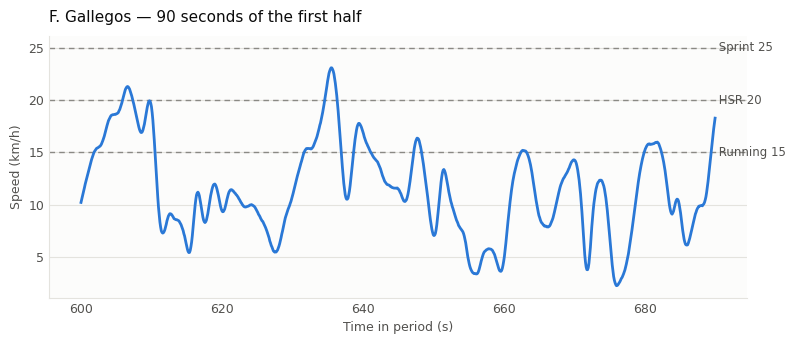

In [11]:
trace = kin[(kin["player_id"] == demo_player) & (kin["period_id"] == 1)]
window = trace[(trace["timestamp"] >= 600) & (trace["timestamp"] <= 690)]

ax = P.plot_speed_trace(window, title=f"{name} — 90 seconds of the first half")
P.save(ax.figure, FIGURES / "tutorial_01_speed_trace.png")
plt.show()

## 3. Speed bands and discrete efforts

Distances sum samples in each band; counts use discrete efforts sustained for **0.7 s**.

| Band | Definition |
|---|---|
| Walking / jogging | < 15 km/h |
| Running | 15 – 20 km/h |
| High-speed running (HSR) | 20 – 25 km/h |
| Sprint | > 25 km/h |
| High intensity | > 20 km/h (HSR ∪ sprint) |

In [12]:
one = kin[kin["player_id"] == demo_player].reset_index(drop=True)
speed_kmh = one["speed_mps"].to_numpy() * 3.6
segment = one["segment_id"].to_numpy()

hsr_mask = speed_kmh >= config.thresholds.hsr_min_kmh

# Every frame above the line, then only the runs that are sustained long enough.
crossings = int(((~np.r_[False, hsr_mask[:-1]]) & hsr_mask).sum())
first, last, seconds = find_efforts(
    hsr_mask, segment, dt=config.dt,
    min_duration=config.speed_activity_min_seconds,
    duration_rule=config.effort_duration_rule,
)
print(f"frames above 20 km/h            : {hsr_mask.sum():,}")
print(f"threshold crossings (naive)     : {crossings}")
print(f"efforts sustained >= 0.7 s      : {len(first)}")
print(f"discarded as chatter            : {crossings - len(first)}")
print(f"effort durations (s)            : {np.round(np.sort(seconds)[::-1][:8], 1)}")

frames above 20 km/h            : 2,240
threshold crossings (naive)     : 85
efforts sustained >= 0.7 s      : 80
discarded as chatter            : 5
effort durations (s)            : [8.6 7.2 6.4 6.2 6.  5.9 5.8 5.4]


Efforts are detected on the continuous speed signal, then attributed to TIP/OTIP.
High-intensity count is `hsr_count + sprint_count`.

In [14]:
player_match = compute_player_match_metrics(tracking, bundle.lineup, config)

cols = ["player_name", "position_group", "played_minutes", "bip_minutes",
        "total_distance_m", "hsr_distance_m", "sprint_distance_m",
        "hsr_count", "sprint_count", "high_intensity_count"]
player_match[cols].sort_values("total_distance_m", ascending=False).head(8).round(1)

,player_name,position_group,played_minutes,bip_minutes,total_distance_m,hsr_distance_m,sprint_distance_m,hsr_count,sprint_count,high_intensity_count
5,F. Gallegos,Midfield,98.4,52.5,9644.5,1157.3,197.5,88,12,100
2,L. Verstraete,Midfield,98.4,52.5,9122.1,698.8,52.7,50,4,54
19,T. Aquilina,Winger,98.4,52.5,8598.7,924.1,215.3,73,16,89
20,K. Grozos,Midfield,98.4,52.5,8515.3,374.3,101.3,31,5,36
12,C. Timmins,Midfield,86.3,47.8,8501.9,563.7,128.0,48,7,55
27,L. Gillion,Winger,98.4,52.5,8485.6,738.4,278.9,67,17,84
0,F. De Vries,Full Back,98.4,52.5,7643.1,658.1,106.6,57,8,65
17,C. Elliott,Full Back,98.4,52.5,7616.0,649.0,153.5,53,10,63


## 4. PSV-99

**PSV-99** is the 99th percentile of activity peak speeds in the 15–40 km/h range.
It uses one observation per activity, not one per frame.

In [16]:
peaks = activity_peak_speeds(one["speed_mps"].to_numpy(), segment, config)
print(f"activities above {config.psv_min_kmh:.0f} km/h : {len(peaks)}")
print(f"their peak speeds (km/h)   : {np.round(np.sort(peaks * 3.6)[::-1][:10], 1)}")

by_hand = np.percentile(np.sort(peaks * 3.6), config.psv_percentile)
from_module = psv(one["speed_mps"].to_numpy(), segment, config)
print(f"\n99th percentile by hand    : {by_hand:.2f} km/h")
print(f"physical.physical_features : {from_module:.2f} km/h")
print(f"single fastest frame       : {speed_kmh.max():.2f} km/h  <- what PSV-99 avoids")

activities above 15 km/h : 220
their peak speeds (km/h)   : [31.3 29.4 28.1 28.  27.9 27.3 27.2 27.  26.5 25.7]

99th percentile by hand    : 28.06 km/h
physical.physical_features : 28.06 km/h
single fastest frame       : nan km/h  <- what PSV-99 avoids


## 5. Accelerations

A high acceleration is `> 3 m/s²` sustained for `>= 0.7 s`. Because acceleration is a
second derivative, estimator choice affects it much more than distance.

In [17]:
from dataclasses import replace

rows = []
for estimator in ["trailing_mean", "savgol", "central"]:
    metrics = compute_player_match_metrics(
        tracking, bundle.lineup, replace(config, estimator=estimator)
    )
    outfield = metrics[(metrics["played_minutes"] >= 60)
                       & (metrics["position_group"] != "Goalkeeper")]
    rows.append({
        "estimator": estimator,
        "total_distance_m_p60_bip": outfield["total_distance_m_p60_bip"].mean(),
        "sprint_count_p60_bip": outfield["sprint_count_p60_bip"].mean(),
        "high_acceleration_count_p60_bip": outfield["high_acceleration_count_p60_bip"].mean(),
    })
sensitivity = pd.DataFrame(rows)
sensitivity.round(2)

,estimator,total_distance_m_p60_bip,sprint_count_p60_bip,high_acceleration_count_p60_bip
0,trailing_mean,9168.45,11.35,4.71
1,savgol,9200.29,12.36,13.43
2,central,9230.66,12.81,13.27


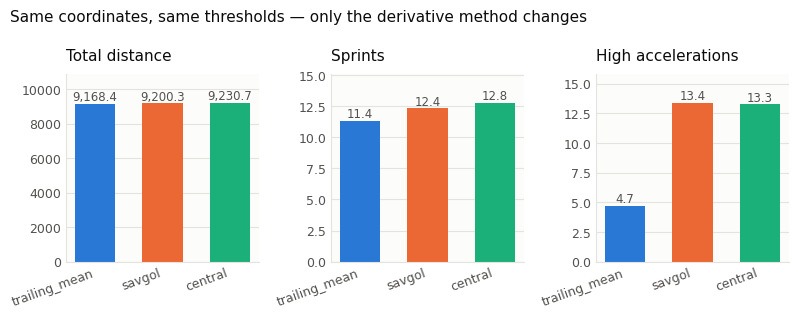

In [18]:
fig = P.plot_estimator_sensitivity(
    sensitivity,
    metric_labels={
        "total_distance_m_p60_bip": "Total distance",
        "sprint_count_p60_bip": "Sprints",
        "high_acceleration_count_p60_bip": "High accelerations",
    },
    title="Same coordinates, same thresholds — only the derivative method changes",
)
P.save(fig, FIGURES / "tutorial_02_estimator_sensitivity.png")
plt.show()

Distance is relatively stable, but acceleration counts change sharply. The default
`trailing_mean` is retained for the legacy benchmark; use `savgol` for the
acceleration-dependent explosiveness reconstruction.

## 6. The denominator that changes the ranking

**P60 BIP** uses:

$$\text{rate}_{P60\ BIP}=\frac{(\text{TIP volume}+\text{OTIP volume})\times 60}{
\text{TIP minutes}+\text{OTIP minutes}}$$

TIP and OTIP are the two possession phases in the Open Data aggregate. Unowned
tracking frames are diagnostic only, not part of the canonical denominator.

In [19]:
compare = player_match[player_match["played_minutes"] >= 60].copy()
compare["total_distance_per90"] = compare["total_distance_m"] * 90 / compare["played_minutes"]

view = compare[["player_name", "position_group", "played_minutes", "bip_minutes",
                "total_distance_m", "total_distance_per90", "total_distance_m_p60_bip"]]
view = view.sort_values("total_distance_m_p60_bip", ascending=False)
view["per90_rank"] = view["total_distance_per90"].rank(ascending=False).astype(int)
view["p60bip_rank"] = view["total_distance_m_p60_bip"].rank(ascending=False).astype(int)
view.head(10).round(1)

,player_name,position_group,played_minutes,bip_minutes,total_distance_m,total_distance_per90,total_distance_m_p60_bip,per90_rank,p60bip_rank
5,F. Gallegos,Midfield,98.4,52.5,9644.5,8821.2,11024.8,3,1
12,C. Timmins,Midfield,86.3,47.8,8501.9,8870.5,10678.1,2,2
2,L. Verstraete,Midfield,98.4,52.5,9122.1,8343.3,10424.9,5,3
24,L. Bayliss,Midfield,61.6,38.2,6421.1,9389.1,10082.4,1,4
1,L. Rogerson,Winger,71.2,40.6,6808.7,8609.0,10062.6,4,5
19,T. Aquilina,Winger,98.4,52.5,8598.7,7864.7,9826.8,7,6
20,K. Grozos,Midfield,98.4,52.5,8515.3,7788.4,9731.5,9,7
27,L. Gillion,Winger,98.4,52.5,8485.6,7761.2,9697.5,10,8
11,J. Brimmer,Forward,77.9,43.6,6756.7,7805.2,9303.2,8,9
22,E. Adams,Winger,86.3,47.8,7349.4,7668.0,9230.6,11,10


## 7. TIP and OTIP — when a player does the running

**TIP** is team-in-possession time and **OTIP** is opponent-in-possession time.
Each is normalised by its own exposure (P30 TIP or P30 OTIP); together they form the
public P60 BIP denominator.

In [20]:
phase_cols = ["player_name", "position_group",
              "tip_minutes", "otip_minutes",
              "high_intensity_distance_tip_m_p30_tip",
              "high_intensity_distance_otip_m_p30_otip"]
player_match.loc[player_match["played_minutes"] >= 60, phase_cols] \
    .sort_values("high_intensity_distance_otip_m_p30_otip", ascending=False).head(8).round(1)

,player_name,position_group,tip_minutes,otip_minutes,high_intensity_distance_tip_m_p30_tip,high_intensity_distance_otip_m_p30_otip
5,F. Gallegos,Midfield,30.1,22.4,566.1,1053.3
1,L. Rogerson,Winger,23.8,16.8,390.9,989.3
11,J. Brimmer,Forward,25.1,18.5,438.2,787.9
9,G. May,Forward,28.3,19.5,390.6,701.2
2,L. Verstraete,Midfield,30.1,22.4,253.6,664.7
17,C. Elliott,Full Back,30.1,22.4,342.3,614.2
27,L. Gillion,Winger,30.1,22.4,589.6,570.0
19,T. Aquilina,Winger,22.4,30.1,782.8,552.2


## 8. Ten matches, and who repeats

One match is a demonstration. To rank anyone we need the players who appear more than
once, so build all ten matches — the CLI does exactly what sections 1–7 did, once per
match, and caches the result.

In [21]:
from physical.build_skillcorner_physical import (
    MINIMUM_MATCHES, MINIMUM_PLAYED_MINUTES,
    add_group_percentiles, build_player_matches, build_player_profiles, qualified_outfield,
)

OUT = root / "tmp/data/physical_opendata"
cached = OUT / "player_matches.parquet"

if cached.exists():
    player_matches = pd.read_parquet(cached)
    coverage = pd.read_parquet(OUT / "coverage.parquet")
    print(f"loaded cache: {len(player_matches)} player-matches")
else:
    # Equivalent to: python -m physical.build_skillcorner_physical --download
    if DATA_SOURCE == "opendata":
        download_skillcorner_opendata(OPENDATA_CACHE)          # ~915 MB with tracking
    player_matches, coverage = build_player_matches(root=DATA_ROOT, season=SEASON)
    OUT.mkdir(parents=True, exist_ok=True)
    player_matches.to_parquet(cached, index=False)
    coverage.to_parquet(OUT / "coverage.parquet", index=False)

qualified = qualified_outfield(player_matches)
profiles = build_player_profiles(qualified)
print(f"eligibility: >= {MINIMUM_PLAYED_MINUTES:.0f} played minutes, >= {MINIMUM_MATCHES} matches, outfield only")
print(f"{len(player_matches)} player-matches -> {len(qualified)} qualifying -> {len(profiles)} season profiles")
print(profiles["matches"].value_counts().sort_index().to_string())

loaded cache: 309 player-matches
eligibility: >= 60 played minutes, >= 2 matches, outfield only
309 player-matches -> 92 qualifying -> 40 season profiles
matches
2    32
3     4
4     4


The ten-match sample uses **two** qualifying matches per player and season volumes use `sum(volume) / sum(exposure)`.

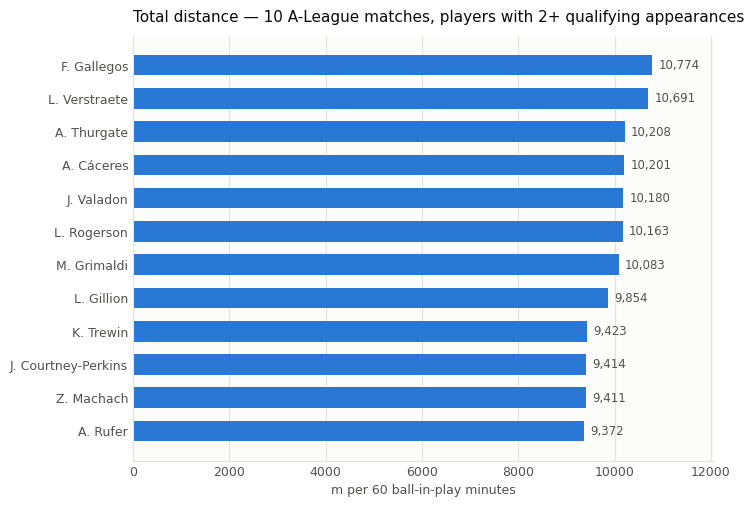

In [22]:
ax = P.plot_leaderboard(
    profiles, "total_distance_m_p60_bip", top_n=12,
    xlabel="m per 60 ball-in-play minutes",
    title="Total distance — 10 A-League matches, players with 2+ qualifying appearances",
)
P.save(ax.figure, FIGURES / "tutorial_03_leaderboard.png")
plt.show()

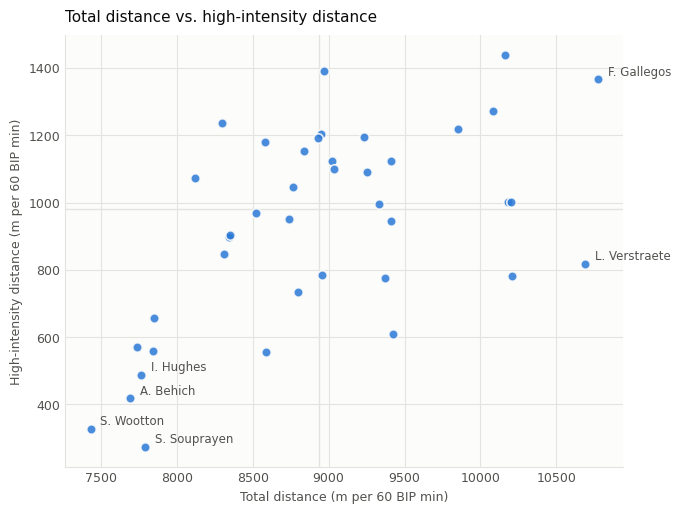

In [24]:
ax = P.plot_volume_vs_intensity(
    profiles,
    title="Total distance vs. high-intensity distance",
)
P.save(ax.figure, FIGURES / "tutorial_04_volume_vs_intensity.png")
plt.show()

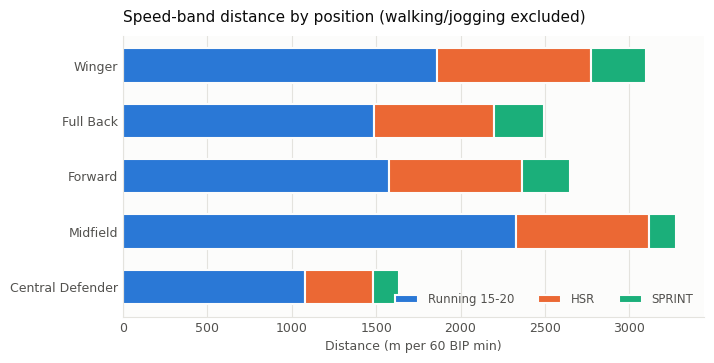

,n,total,high_intensity,sprints,psv99
position_group,,,,,
Central Defender,23,7995.5,554.6,9.6,30.3
Full Back,22,8668.6,1006.6,16.3,30.3
Forward,13,8872.9,1072.5,15.4,30.5
Winger,16,9418.1,1239.1,19.5,29.5
Midfield,18,10173.2,948.0,10.7,28.2


In [25]:
ax = P.plot_band_composition(
    qualified, title="Speed-band distance by position (walking/jogging excluded)",
)
P.save(ax.figure, FIGURES / "tutorial_05_bands_by_position.png")
plt.show()

group = qualified.groupby("position_group", observed=True).agg(
    n=("player_id", "size"),
    total=("total_distance_m_p60_bip", "mean"),
    high_intensity=("high_intensity_distance_m_p60_bip", "mean"),
    sprints=("sprint_count_p60_bip", "mean"),
    psv99=("psv99_kmh", "mean"),
).round(1).sort_values("total")
group

Volume, high-intensity distance and sprint counts produce different position orders.
The CB–Winger PSV-99 ordering remains unexplained and is flagged rather than corrected.

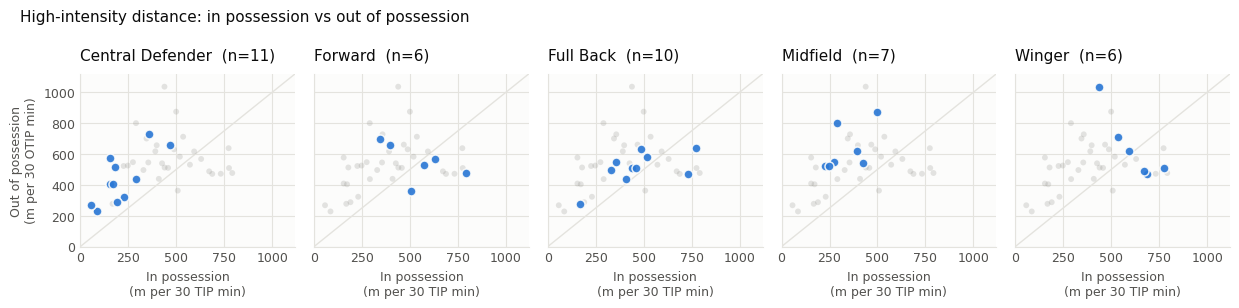

In [26]:
fig = P.plot_tip_otip_facets(
    profiles, title="High-intensity distance: in possession vs out of possession",
)
P.save(fig, FIGURES / "tutorial_06_tip_otip.png")
plt.show()

The plot compares high-intensity distance per minute in TIP and OTIP.

## 9. Off-ball runs by phase

The physical table says how much a player ran. SkillCorner's Dynamic Events say *when* —
each off-ball run is tagged with the phase of play it happened in. This is a different
file and a different unit of observation, so it is kept beside the tracking metrics rather
than joined frame-by-frame onto them.

In [27]:
runs = []
for match_id in OPENDATA_MATCH_IDS:
    events_path = resolve_match_files(match_id, DATA_ROOT)["dynamic_events"]
    if events_path is None:
        continue
    runs.append(load_dynamic_events(events_path, event_types=("off_ball_run",)))
runs = pd.concat(runs, ignore_index=True)

print(f"{len(runs):,} off-ball runs over {runs['match_id'].nunique()} matches")
print()
print(runs["speed_avg_band"].value_counts(dropna=False).to_string())
print()
print(runs["team_in_possession_phase_type"].value_counts().to_string())

5,002 off-ball runs over 10 matches

speed_avg_band
running      3747
hsr          1020
sprinting     156
NaN            79

team_in_possession_phase_type
create         1839
finish         1486
build_up        641
transition      280
chaotic         259
direct          223
quick_break     128
set_play        120
disruption       26


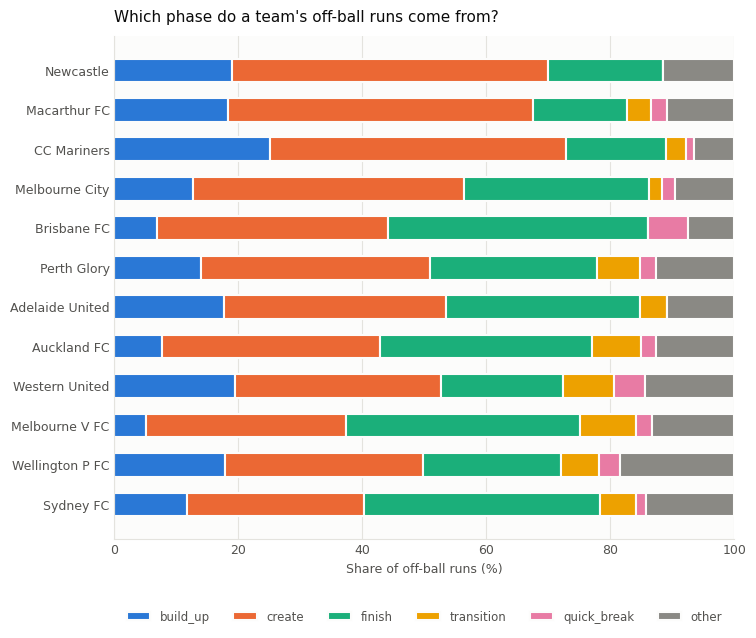

In [28]:
TOP_PHASES = ["build_up", "create", "finish", "transition", "quick_break"]

phase = runs.copy()
phase["phase"] = phase["team_in_possession_phase_type"].where(
    phase["team_in_possession_phase_type"].isin(TOP_PHASES), "other"
)
shares = (
    pd.crosstab(phase["team_shortname"], phase["phase"], normalize="index")
    .reindex(columns=TOP_PHASES + ["other"], fill_value=0.0)
)
shares = shares.loc[shares["create"].sort_values().index]

ax = P.plot_phase_share(shares, title="Which phase do a team's off-ball runs come from?")
P.save(ax.figure, FIGURES / "tutorial_07_phase_share.png")
plt.show()

Rare phases are grouped as `other` to keep the stacked bar readable.

## 10. Explosiveness — how fast a player gets up to speed

`physical.explosiveness` times crossings of 20 and 25 km/h after a sustained
acceleration, with an optional post-turn clock. It is a transparent reconstruction,
not SkillCorner's proprietary explosive-acceleration product. Run it with `savgol`.

In [29]:
from physical.explosiveness import extract_reconstructed_efforts

# Explosiveness reads the acceleration signal, so it needs an estimator that smooths
# position and then differentiates. Under the default trailing_mean -- which averages
# *speed* over a 1-second window -- the acceleration peaks are flattened (section 5) and
# almost nothing clears the 3 m/s² threshold.
kin_savgol = prepare_kinematics(tracking, bundle.lineup, replace(config, estimator="savgol"))
efforts = extract_reconstructed_efforts(kin_savgol)

print(f"{len(efforts)} reconstructed efforts in one match\n")
efforts.groupby(["family", "target"]).agg(
    n=("time_seconds", "size"),
    mean_seconds=("time_seconds", "mean"),
    fastest=("time_seconds", "min"),
    ball_in_play=("bip_attributed", "mean"),
).round(2)

227 reconstructed efforts in one match



n  mean_seconds  fastest  ball_in_play
family                 target                                          
post_cod_time_to_speed hsr       8          1.17     0.52          0.88
                       sprint    6          2.13     0.73          0.83
time_to_speed          hsr     152          1.30     0.42          0.96
                       sprint   61          2.05     0.67          0.93

In [30]:
fastest = (
    efforts[efforts["target"] == "hsr"]
    .groupby(["player_name", "position_group"], observed=True)["time_seconds"]
    # A player's best three efforts, so one lucky run does not define them.
    .apply(lambda s: s.nsmallest(3).mean())
    .reset_index(name="seconds_to_hsr")
    .sort_values("seconds_to_hsr")
)
print("time to 20 km/h — mean of each player's three fastest efforts\n")
# fastest.head(8).round(2).to_string(index=False)
fastest.head(8).round(2)

time to 20 km/h — mean of each player's three fastest efforts



,player_name,position_group,seconds_to_hsr
17,L. Rogerson,Winger,0.58
6,D. Ingham,Full Back,0.60
25,R. Scott,Goalkeeper,0.71
10,F. Gallegos,Midfield,0.71
20,M. Natta,Full Back,0.75
2,C. Elliott,Full Back,0.77
7,D. Wilmering,Midfield,0.80
9,F. De Vries,Full Back,0.82


## 11. The reusable package

Each step has a reusable module:

| Step | Module |
|---|---|
| Download, stream, lineup | `physical.skillcorner_tracking` |
| Thresholds and config | `physical.definitions` |
| Segmentation, smoothing, caps | `physical.kinematics` |
| Bands, efforts, PSV-99, TIP/OTIP, rates | `physical.physical_features` |
| Eligibility and league aggregation | `physical.normalize` |
| Time-to-speed and post-turn efforts | `physical.explosiveness` |
| Match loop, profiles, percentiles | `physical.build_skillcorner_physical` |
| Figures | `physical.physical_plots` |

Rebuild the cached table with:

```bash
python -m physical.build_skillcorner_physical --download
```

Run the synthetic tests with:

```bash
python -m pytest physical/tests -q
```

The metric definition travels with the number: speed bands, effort duration, TIP/OTIP
exposure, PSV-99 range, estimator and extrapolation quality all affect interpretation.